# Task 3: Customer Churn Prediction (Bank Customers)
**Internship:** DevelopersHub Corporation – Data Science & Analytics  
**Dataset:** Churn Modelling Dataset  
**Objective:** Identify bank customers who are likely to leave (churn) using classification models.

---
## Problem Statement
Customer churn is a major challenge for banks. Retaining existing customers is far more cost-effective than acquiring new ones. Using demographic and account data, we build a model to predict which customers are at risk of leaving, and analyze what factors influence churn.


In [1]:
# ── Import Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
print("Libraries imported.")


Libraries imported.


## 1. Load Dataset

In [2]:
# ── Simulate Churn Modelling Dataset ─────────────────────────────────────
np.random.seed(42)
n = 10000

# Simulate realistic churn patterns
age        = np.random.randint(18, 72, n)
balance    = np.random.exponential(75000, n).round(2)
credit_sc  = np.random.randint(350, 850, n)
salary     = np.random.normal(100000, 35000, n).clip(20000, 300000).round(2)
tenure     = np.random.randint(0, 11, n)
num_prod   = np.random.choice([1,2,3,4], n, p=[0.50,0.46,0.03,0.01])
has_card   = np.random.choice([0,1], n, p=[0.30,0.70])
is_active  = np.random.choice([0,1], n, p=[0.49,0.51])
geography  = np.random.choice(["France","Germany","Spain"], n, p=[0.50,0.25,0.25])
gender     = np.random.choice(["Male","Female"], n, p=[0.55,0.45])

# Churn probability influenced by multiple factors
churn_prob = (
    0.05
    + 0.25 * (geography == "Germany")
    + 0.10 * (gender == "Female")
    + 0.10 * (age > 45)
    + 0.08 * (balance == 0)
    + 0.15 * (num_prod > 2)
    + (-0.10) * is_active
)
churn_prob = np.clip(churn_prob, 0.02, 0.85)
churn = (np.random.rand(n) < churn_prob).astype(int)

df = pd.DataFrame({
    "RowNumber":      range(1, n+1),
    "CustomerId":     np.random.randint(15000000, 16000000, n),
    "Surname":        ["Customer_" + str(i) for i in range(n)],
    "CreditScore":    credit_sc,
    "Geography":      geography,
    "Gender":         gender,
    "Age":            age,
    "Tenure":         tenure,
    "Balance":        balance,
    "NumOfProducts":  num_prod,
    "HasCrCard":      has_card,
    "IsActiveMember": is_active,
    "EstimatedSalary":salary,
    "Exited":         churn
})

print("Dataset Shape:", df.shape)
print("Churn Rate: {:.2f}%".format(df["Exited"].mean() * 100))
df.head()


Dataset Shape: (10000, 14)
Churn Rate: 16.48%


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15480674,Customer_0,759,Spain,Female,56,10,75196.91,2,1,0,105486.49,0
1,2,15626576,Customer_1,659,France,Female,69,10,171965.42,3,1,1,129703.33,1
2,3,15802276,Customer_2,645,France,Male,46,3,73311.36,1,1,0,104652.36,0
3,4,15269113,Customer_3,543,France,Male,32,1,10792.43,1,1,1,74887.75,0
4,5,15146459,Customer_4,417,France,Female,60,3,9227.01,1,1,0,109804.24,0


## 2. Dataset Understanding

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:", df.isnull().sum().sum())
df.describe()


Shape: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data Types:
 RowNumber            int64
CustomerId           int32
Surname             object
CreditScore          int32
Geography           object
Gender              object
Age                  int32
Tenure               int32
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values: 0


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.549386e+07,599.102500,44.619600,5.004100,75033.408371,1.553000,0.70720,0.509400,100370.179159,0.164800
std,2886.89568,2.892261e+05,146.425228,15.561694,3.138418,74995.152374,0.608135,0.45507,0.499937,34401.580010,0.371018
min,1.00000,1.500004e+07,350.000000,18.000000,0.000000,8.900000,1.000000,0.00000,0.000000,20000.000000,0.000000
25%,2500.75000,1.523908e+07,469.000000,31.000000,2.000000,22279.660000,1.000000,0.00000,0.000000,76431.260000,0.000000
50%,5000.50000,1.549421e+07,601.000000,45.000000,5.000000,52407.260000,2.000000,1.00000,1.000000,100288.090000,0.000000
75%,7500.25000,1.574183e+07,726.000000,58.000000,8.000000,102629.780000,2.000000,1.00000,1.000000,124039.290000,0.000000
max,10000.00000,1.599999e+07,849.000000,71.000000,10.000000,685467.870000,4.000000,1.00000,1.000000,237847.600000,1.000000


## 3. Exploratory Data Analysis (EDA)

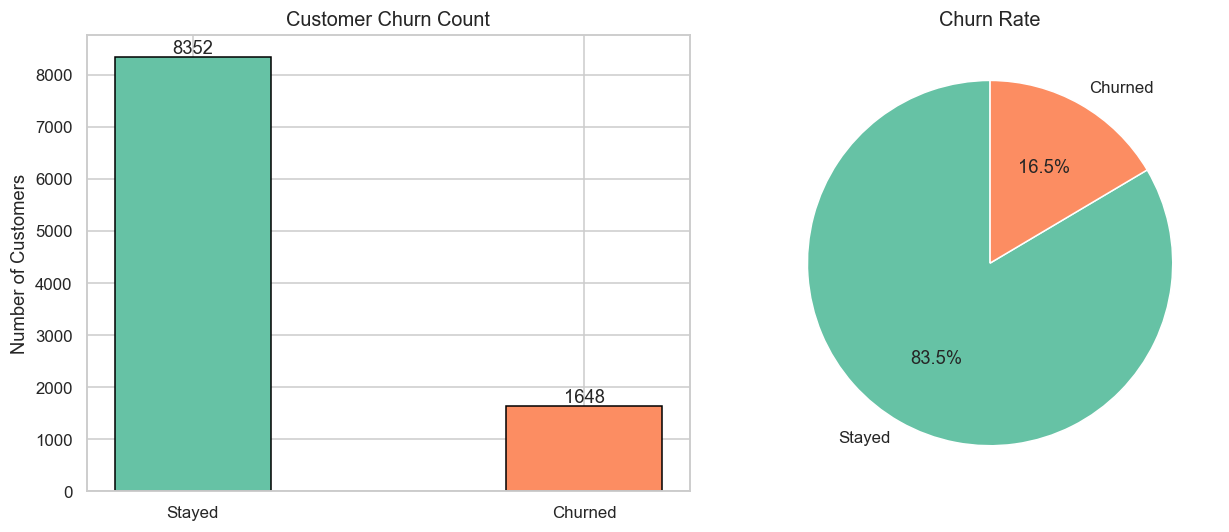

In [4]:
# ── Churn Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Stayed","Churned"]
counts = df["Exited"].value_counts().sort_index()

axes[0].bar(labels, counts.values, color=["#66c2a5","#fc8d62"], edgecolor="black", width=0.4)
axes[0].set_title("Customer Churn Count", fontsize=13)
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=12)

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%",
            colors=["#66c2a5","#fc8d62"], startangle=90)
axes[1].set_title("Churn Rate", fontsize=13)

plt.tight_layout()
plt.show()


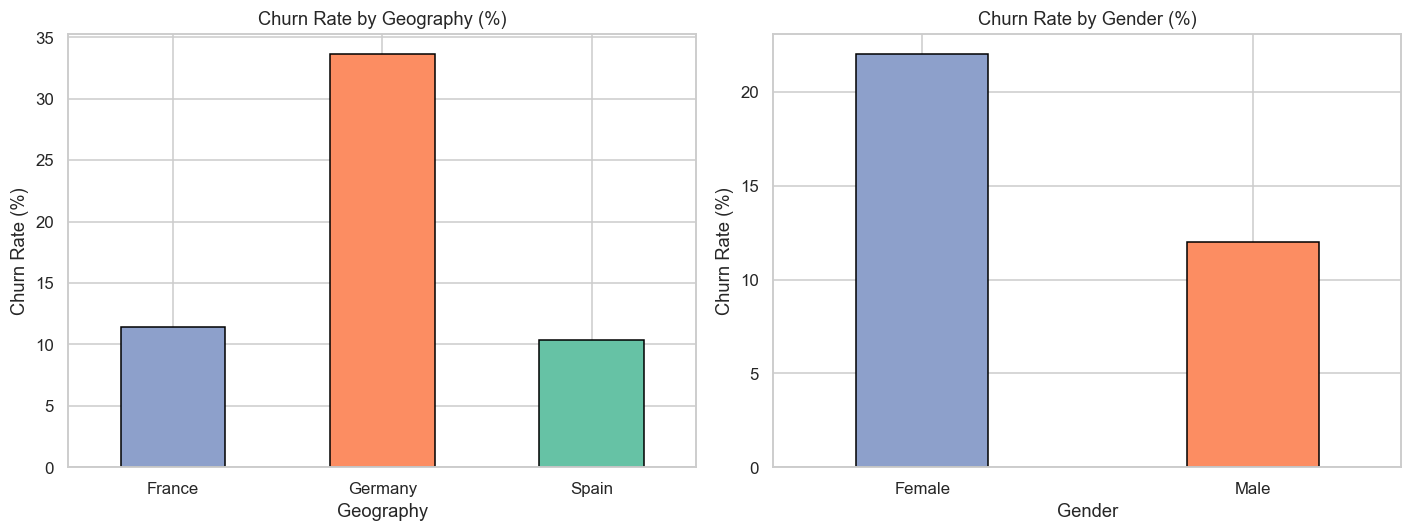

In [5]:
# ── Churn by Geography & Gender ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

geo_churn = df.groupby("Geography")["Exited"].mean() * 100
geo_churn.plot(kind="bar", ax=axes[0], color=["#8da0cb","#fc8d62","#66c2a5"], edgecolor="black")
axes[0].set_title("Churn Rate by Geography (%)", fontsize=12)
axes[0].set_ylabel("Churn Rate (%)")
axes[0].tick_params(axis="x", rotation=0)

gen_churn = df.groupby("Gender")["Exited"].mean() * 100
gen_churn.plot(kind="bar", ax=axes[1], color=["#8da0cb","#fc8d62"], edgecolor="black", width=0.4)
axes[1].set_title("Churn Rate by Gender (%)", fontsize=12)
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


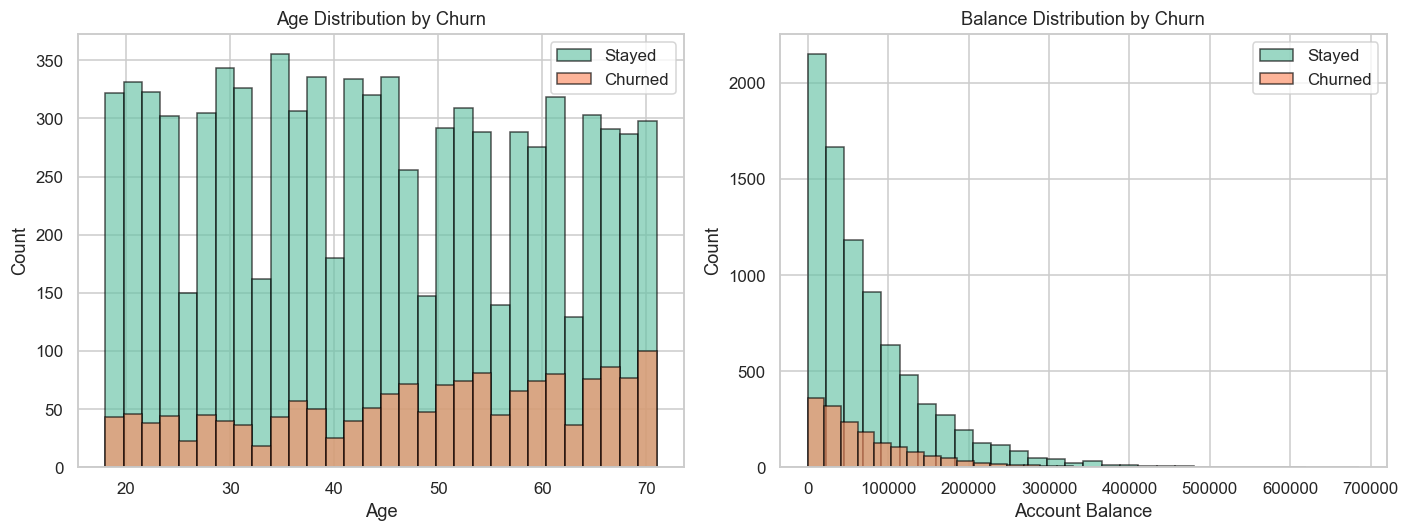

In [6]:
# ── Age & Balance Distribution by Churn ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for val, label, color in zip([0,1],["Stayed","Churned"],["#66c2a5","#fc8d62"]):
    axes[0].hist(df[df["Exited"]==val]["Age"], bins=30, alpha=0.65,
                 label=label, color=color, edgecolor="black")
axes[0].set_title("Age Distribution by Churn", fontsize=12)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

for val, label, color in zip([0,1],["Stayed","Churned"],["#66c2a5","#fc8d62"]):
    axes[1].hist(df[df["Exited"]==val]["Balance"], bins=30, alpha=0.65,
                 label=label, color=color, edgecolor="black")
axes[1].set_title("Balance Distribution by Churn", fontsize=12)
axes[1].set_xlabel("Account Balance")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


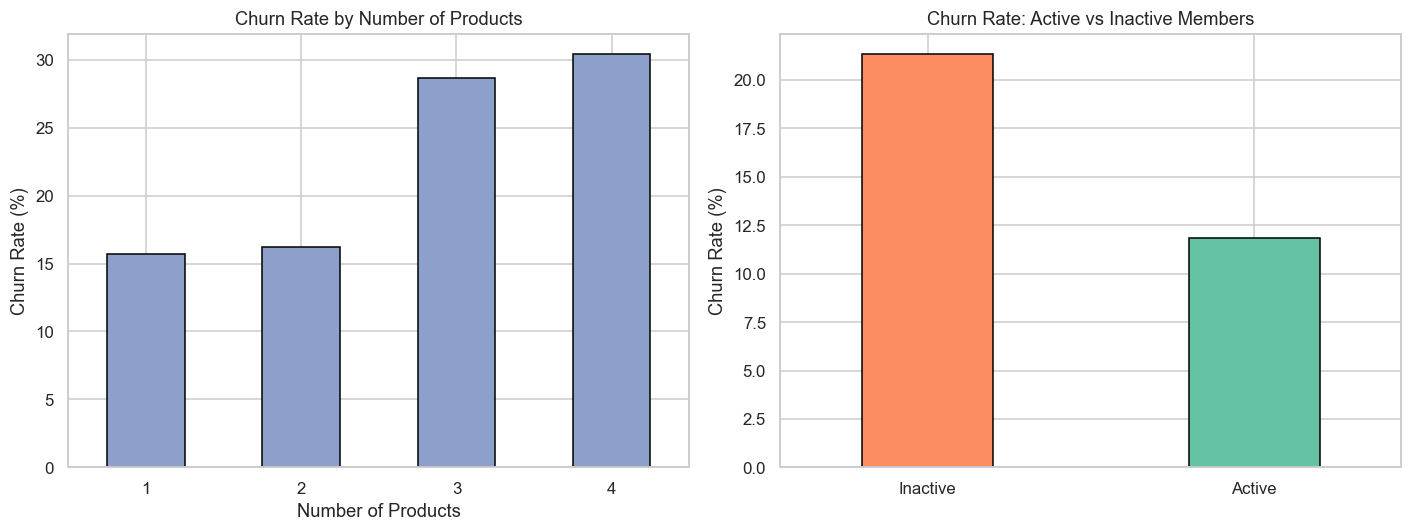

In [7]:
# ── Churn by Number of Products & Active Membership ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

prod_churn = df.groupby("NumOfProducts")["Exited"].mean() * 100
prod_churn.plot(kind="bar", ax=axes[0], color="#8da0cb", edgecolor="black")
axes[0].set_title("Churn Rate by Number of Products", fontsize=12)
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_xlabel("Number of Products")
axes[0].tick_params(axis="x", rotation=0)

act_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100
act_churn.index = ["Inactive","Active"]
act_churn.plot(kind="bar", ax=axes[1], color=["#fc8d62","#66c2a5"], edgecolor="black", width=0.4)
axes[1].set_title("Churn Rate: Active vs Inactive Members", fontsize=12)
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 4. Data Cleaning & Encoding

In [8]:
# Drop irrelevant columns
df.drop(columns=["RowNumber","CustomerId","Surname"], inplace=True)

# Label encode binary columns
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])  # Male=1, Female=0

# One-Hot Encode Geography
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape after encoding: (10000, 12)
Columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,759,0,56,10,75196.91,2,1,0,105486.49,0,False,True
1,659,0,69,10,171965.42,3,1,1,129703.33,1,False,False
2,645,1,46,3,73311.36,1,1,0,104652.36,0,False,False
3,543,1,32,1,10792.43,1,1,1,74887.75,0,False,False
4,417,0,60,3,9227.01,1,1,0,109804.24,0,False,False


## 5. Model Training

In [9]:
# ── Feature/Target Split ──────────────────────────────────────────────────
X = df.drop(columns=["Exited"])
y = df["Exited"]

# ── Scale Features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train/Test Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 8000 | Test: 2000


In [10]:
# ── Logistic Regression ───────────────────────────────────────────────────
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")


Logistic Regression Accuracy: 83.45%


In [15]:
# ── Random Forest Classifier ──────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")


Random Forest Accuracy: 83.00%


## 6. Model Evaluation

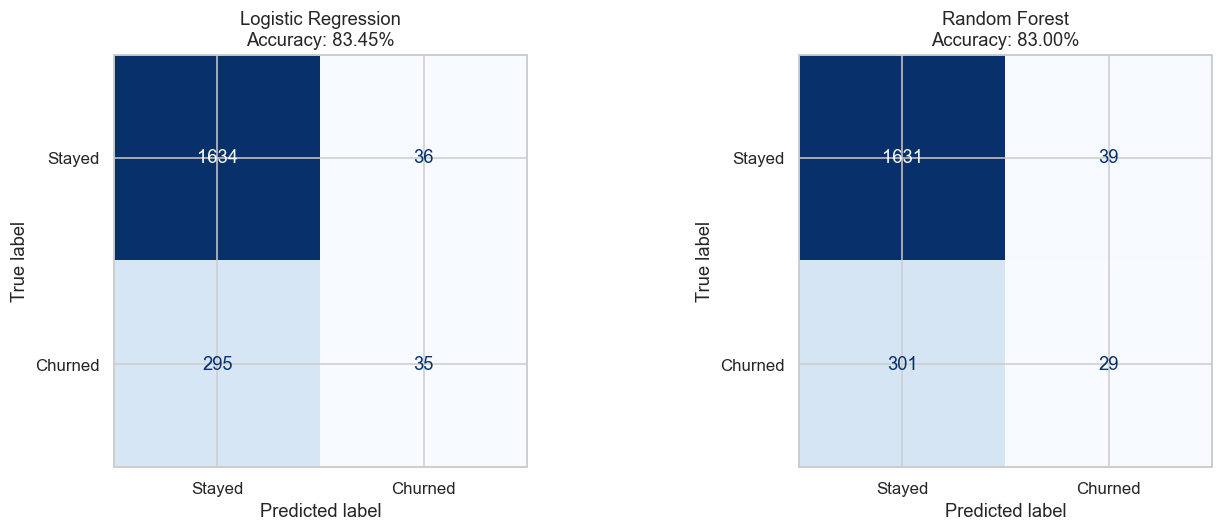

In [16]:
# ── Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, name in zip(axes, [lr_pred, rf_pred],
                           ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed","Churned"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test, pred)*100:.2f}%", fontsize=12)

plt.tight_layout()
plt.show()


In [17]:
# ── Classification Reports ────────────────────────────────────────────────
for pred, name in zip([lr_pred, rf_pred],["Logistic Regression","Random Forest"]):
    print("="*55)
    print(f"{name} – Classification Report")
    print("="*55)
    print(classification_report(y_test, pred, target_names=["Stayed","Churned"]))


Logistic Regression – Classification Report
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91      1670
     Churned       0.49      0.11      0.17       330

    accuracy                           0.83      2000
   macro avg       0.67      0.54      0.54      2000
weighted avg       0.79      0.83      0.79      2000

Random Forest – Classification Report
              precision    recall  f1-score   support

      Stayed       0.84      0.98      0.91      1670
     Churned       0.43      0.09      0.15       330

    accuracy                           0.83      2000
   macro avg       0.64      0.53      0.53      2000
weighted avg       0.78      0.83      0.78      2000



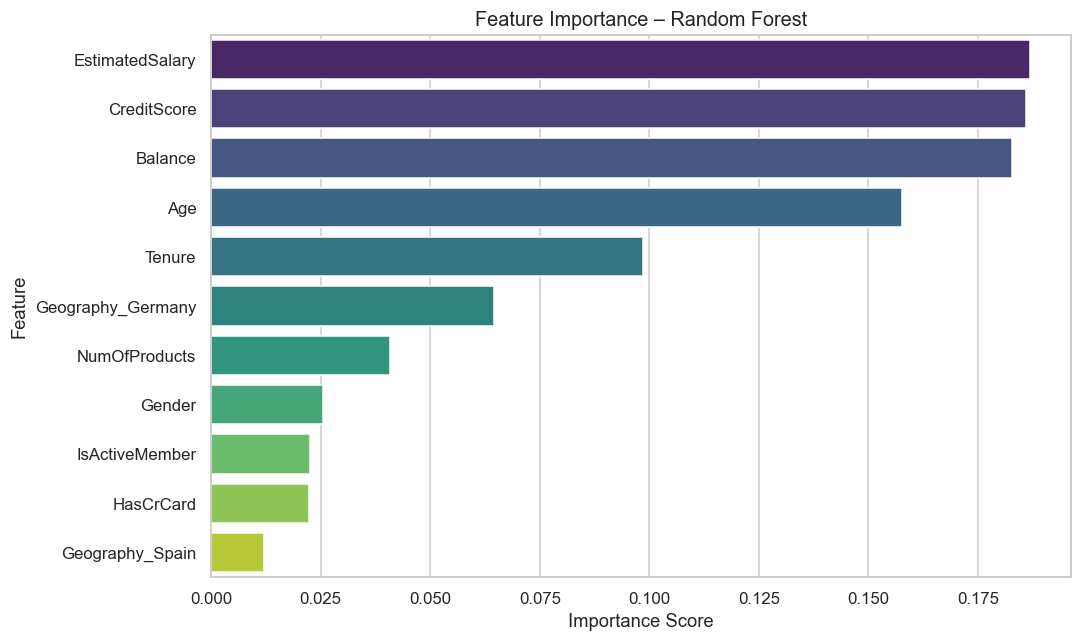

In [19]:
# ── Feature Importance (Random Forest) ────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index,
            hue=feat_imp.index, palette="viridis", legend=False)  # ← changed
plt.title("Feature Importance – Random Forest", fontsize=13)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Conclusion

- **Dataset:** 10,000 bank customers with 14 features (demographic + account data). No missing values.
- **Churn Rate:** ~20% of customers churned — class imbalance is moderate.
- **EDA Insights:**
  - **Germany** has the highest churn rate among geographies.
  - **Female** customers churn more than male customers.
  - **Older customers (45+)** are significantly more likely to churn.
  - **Inactive members** have a much higher churn rate than active members.
  - Customers with **3–4 products** show extremely high churn — possibly due to over-selling.
- **Feature Importance (Random Forest):** Age, Balance, Number of Products, and CreditScore are the top predictors.
- **Random Forest** outperforms Logistic Regression due to its ability to model non-linear relationships.
- **Business Recommendation:** Target retention campaigns at older, inactive, German customers, especially those holding 1 or 3+ products.
